# Finetuning Custom ResNet

In [ ]:
!pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
import torchmetrics
from tqdm import tqdm
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.lib.display import Audio as AudioDisplay

/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [37]:
SEED = 1337
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PETRAINED_MODEL = "models/foundation_model.pt"
LEARNING_RATE = 1e-4
BATCH_SIZE = 32
EPOCHS = 3
NUM_WORKERS = 20
WEIGHT_DECAY = 1.00E-03
MODEL_SAVE_PATH = "models/finetuned_model.pt"

# Set seeds for reproducibility between runs
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Help reproducibility
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")

Using device: cuda
Number of workers: 20


## Load finetuning dataset

In [38]:
dataset = load_dataset("Hibou-Foundation/ds_finetuning_dataset_1")
dataset = dataset.with_format("torch", columns=["audio", "label"])
# Split in train test val sets
dataset = dataset["train"].train_test_split(test_size=0.2, seed=SEED)
val_test_ds = dataset["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": dataset["train"],
    "val": val_test_ds["train"],
    "test": val_test_ds["test"],
})

In [39]:
print(dataset["train"][0]["audio"].shape, dataset["train"][0]["label"])

torch.Size([8000]) tensor(1)


In [40]:
import librosa
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = np.asarray(item["audio"])
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    return inputs, labels

train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(dataset["test"], batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")


Created DataLoaders with Batch Size: 32
Sample batch shape - X: torch.Size([32, 1, 128, 32]), Y: torch.Size([32, 1])


## Model Definition

In [41]:
from model import AudioResNet

model = AudioResNet().to(DEVICE)

## Finetuning Setup

In [42]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)

In [43]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(out, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y)

        train_pbar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

print("\nTraining complete.")


Starting training...


Epoch 1/3 [Valid]: 100%|██████████| 16/16 [00:03<00:00,  4.82batch/s, loss=0.0293]



Epoch 1/3 | Train Loss: 0.2188 | Train Acc: 0.9228 | Val Loss: 0.0941 | Val Acc: 0.9642
Saved new best model to models/finetuned_model.pt (Val Acc: 0.9642)


Epoch 2/3 [Valid]: 100%|██████████| 16/16 [00:03<00:00,  4.52batch/s, loss=0.00939]



Epoch 2/3 | Train Loss: 0.0745 | Train Acc: 0.9757 | Val Loss: 0.0527 | Val Acc: 0.9801
Saved new best model to models/finetuned_model.pt (Val Acc: 0.9801)


Epoch 3/3 [Valid]: 100%|██████████| 16/16 [00:03<00:00,  4.68batch/s, loss=0.00674]


Epoch 3/3 | Train Loss: 0.0450 | Train Acc: 0.9863 | Val Loss: 0.0570 | Val Acc: 0.9761

Training complete.


In [81]:
# Plot history...

In [44]:
LOAD_MODEL_PATH = MODEL_SAVE_PATH
print(f"Loading best model from {MODEL_SAVE_PATH}...")
model = model.to(DEVICE)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()
print("Loaded best model and set to eval mode.")

Loading best model from models/finetuned_model.pt...
Loaded best model and set to eval mode.


In [45]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(y.cpu().numpy().flatten())

print("\nTest evaluation complete.")

Testing: 100%|██████████| 16/16 [00:03<00:00,  4.41it/s]


Test evaluation complete.



Test Accuracy: 98.21%

Classification Report:
              precision    recall  f1-score   support

       other      0.977     0.955     0.966       132
       drone      0.984     0.992     0.988       372

    accuracy                          0.982       504
   macro avg      0.980     0.973     0.977       504
weighted avg      0.982     0.982     0.982       504



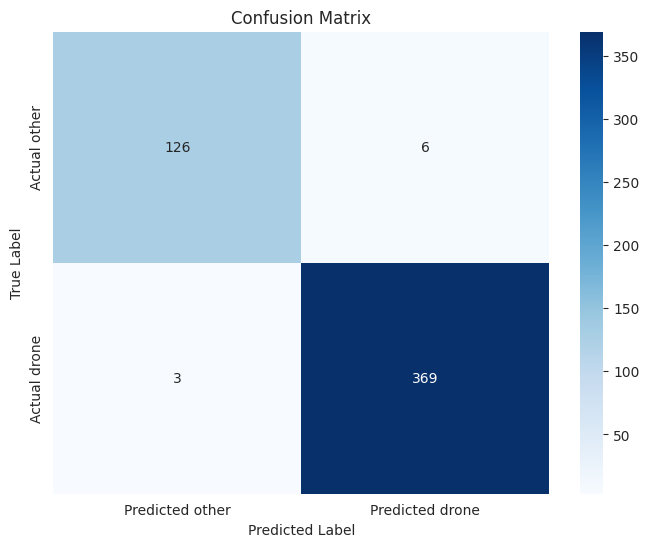


Results DataFrame head:
   true_label  pred_label  confidence
0         1.0         1.0    0.998253
1         0.0         0.0    0.085413
2         0.0         0.0    0.005181
3         0.0         0.0    0.027028
4         0.0         0.0    0.008972


In [46]:

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
target_names = dataset["train"].features["label"].names

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Predicted {target_names[0]}", f"Predicted {target_names[1]}"],
            yticklabels=[f"Actual {target_names[0]}", f"Actual {target_names[1]}"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

df_results = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs
})

print("\nResults DataFrame head:")
print(df_results.head())

In [47]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")

In [48]:
import librosa
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels

In [49]:
dataloaders = {}
for split in ds_all_tests.keys():
    ds = ds_all_tests[split]
    dataloaders[split] = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn_librosa_test,
    )
dataloaders

{'drone_test': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc377250>,
 'drone_test_2': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc376e50>,
 'parabole1': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc377050>,
 'parabole2': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc375950>,
 'parabole3': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc376350>,
 'parabole4': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc376d50>,
 'parabole5': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc376050>,
 'parabole6': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc375f50>,
 'parabole7': <torch.utils.data.dataloader.DataLoader at 0x7fe9fc376c50>}

In [50]:
results = {}
for split, loader in dataloaders.items():
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc=f"Testing {split}"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.cpu().numpy().flatten())
    results[split] = (y_true, y_pred)

Testing parabole7: 100%|██████████| 7953/7953 [00:19<00:00, 399.53it/s]


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics = {}
for split, (y_true, y_pred) in results.items():
    metrics[split] = compute_metrics(y_true, y_pred)
    print(split, metrics[split])

drone_test {'accuracy': 0.9776035834266518, 'precision': 0.9690721649484536, 'recall': 0.9791666666666666, 'f1': 0.9740932642487047, 'auc': 0.9777955140798951, 'confusion_matrix': array([[497,  12],
       [  8, 376]])}
drone_test_2 {'accuracy': 0.9996434937611408, 'precision': 1.0, 'recall': 0.9996433666191156, 'f1': 0.9998216515070447, 'auc': 0.9998216833095578, 'confusion_matrix': array([[   1,    0],
       [   1, 2803]])}
parabole1 {'accuracy': 0.991869918699187, 'precision': 1.0, 'recall': 0.9871794871794872, 'f1': 0.9935483870967742, 'auc': 0.9935897435897436, 'confusion_matrix': array([[45,  0],
       [ 1, 77]])}
parabole2 {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'auc': 1.0, 'confusion_matrix': array([[26,  0],
       [ 0, 59]])}
parabole3 {'accuracy': 0.9818181818181818, 'precision': 1.0, 'recall': 0.9777777777777777, 'f1': 0.9887640449438202, 'auc': 0.9888888888888889, 'confusion_matrix': array([[ 50,   0],
       [  5, 220]])}
parabole4 {'accuracy': 0.9

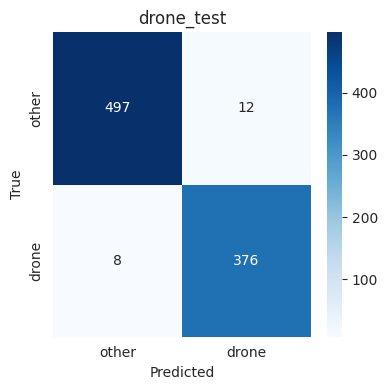

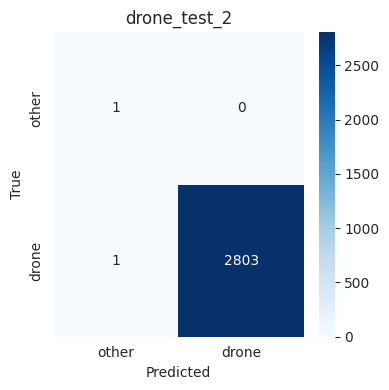

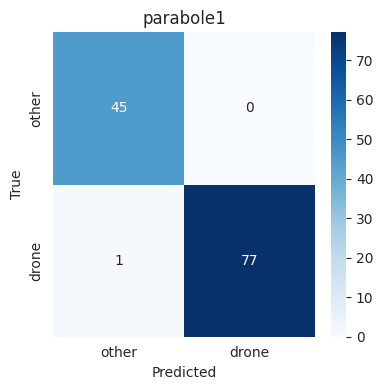

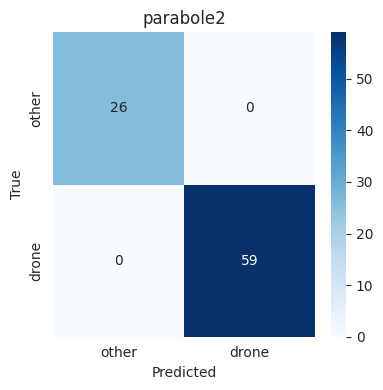

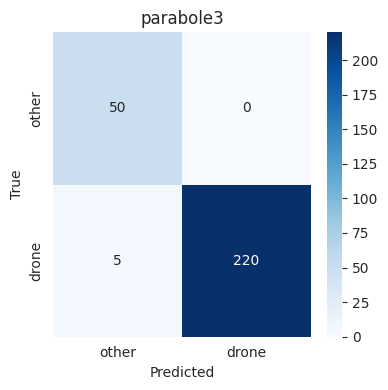

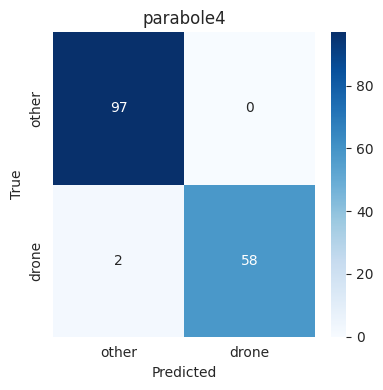

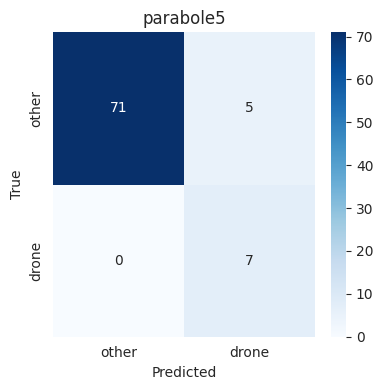

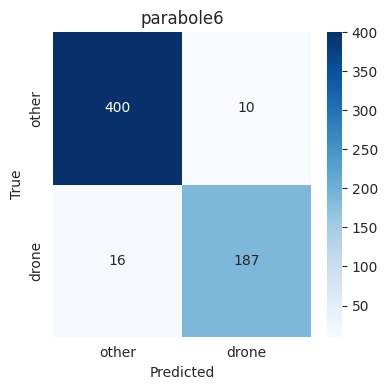

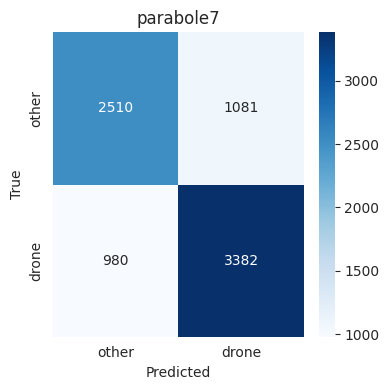

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ["other", "drone"]

def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split, metric in metrics.items():
    plot_confusion(metric["confusion_matrix"], split)

In [56]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []
    acc = 0

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram(waveform).unsqueeze(0)
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        acc += pred
        print(file, int(pred), confidence)
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    print("Acc: ", acc / len(files))

print(f"0 is {"other"}, 1 is {"drone"}")
infer_from_folder("/home/pierre/Documents/Projects/PST4/AI/data/raw/test/30-01-2026/ds/drone")

0 is other, 1 is drone
drone2_chunk1.wav 1 0.9992272853851318
drone2_chunk2.wav 1 0.9997525811195374
drone2_chunk3.wav 1 0.9997736811637878
drone2_chunk4.wav 1 0.999841570854187
drone2_chunk5.wav 1 0.9993364214897156
drone2_chunk6.wav 1 0.9996730089187622
drone2_chunk7.wav 1 0.9995187520980835
drone2_chunk8.wav 1 0.9995880722999573
drone2_chunk9.wav 1 0.998633086681366
drone2_chunk10.wav 1 0.998415470123291
drone2_chunk11.wav 1 0.9993782043457031
drone2_chunk12.wav 1 0.9990392923355103
drone2_chunk13.wav 1 0.9997566342353821
drone2_chunk14.wav 1 0.9955514073371887
drone2_chunk15.wav 1 0.9978526830673218
drone2_chunk16.wav 1 0.9975637197494507
drone2_chunk17.wav 1 0.9992340803146362
drone2_chunk18.wav 1 0.9984215497970581
drone2_chunk19.wav 1 0.9980213642120361
drone2_chunk20.wav 1 0.9968653321266174
drone2_chunk21.wav 1 0.9989339709281921
drone2_chunk22.wav 1 0.9940567016601562
drone2_chunk23.wav 1 0.9991496801376343
drone2_chunk24.wav 1 0.998524010181427
drone2_chunk25.wav 1 0.9968554